# Emotional Monitoring

### Load Libraries

In [7]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [8]:
# load dataset
df = pd.read_csv('../../Datasets/emotional_monitoring/emotional_monitoring_dataset_with_target.csv')
df.head()

,HeartRate,SkinConductance,EEG,Temperature,PupilDiameter,SmileIntensity,FrownIntensity,CortisolLevel,ActivityLevel,AmbientNoiseLevel,LightingLevel,EmotionalState,CognitiveState,EngagementLevel
0,61,8.937204,11.794946,36.501723,3.330181,0.689238,0.189024,0.603035,136,59,394,engaged,distracted,3
1,60,12.635397,19.151412,36.618910,3.428995,0.561056,0.091367,0.566671,155,39,479,engaged,distracted,1
2,81,3.660028,6.226098,36.176898,2.819286,0.417951,0.227355,1.422475,55,30,832,partially engaged,focused,3
3,119,0.563070,4.542968,37.205293,2.192961,0.140186,0.502965,1.669045,39,40,602,disengaged,focused,3
4,118,0.477378,0.996209,37.248118,2.450139,0.064471,0.695604,1.854076,10,42,908,disengaged,focused,3


In [9]:
df.columns

Index(['HeartRate', 'SkinConductance', 'EEG', 'Temperature', 'PupilDiameter',
       'SmileIntensity', 'FrownIntensity', 'CortisolLevel', 'ActivityLevel',
       'AmbientNoiseLevel', 'LightingLevel', 'EmotionalState',
       'CognitiveState', 'EngagementLevel'],
      dtype='object')

In [10]:
# Encode categorical features
le_emotionalState = LabelEncoder()
le_cognitiveState = LabelEncoder()
df['EmotionalState'] = le_emotionalState.fit_transform(df['EmotionalState'])
df['CognitiveState'] = le_cognitiveState.fit_transform(df['CognitiveState'])

In [11]:
# Seprate features and target
X = df.drop(columns=['EngagementLevel'])
y = df['EngagementLevel']

# Adjust labels to start from 0 for PyTorch
y = y - y.min()
num_classes = len(y.unique())

# Splite data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

In [12]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Dataset shape: {X.shape}')
print(f'# classes: {num_classes}')
print(f'Class distribution: {np.bincount(y)}\n')

Dataset shape: (1000, 13)
# classes: 3
Class distribution: [ 97 324 579]



In [13]:
# Encode categorical features
le_emotional = LabelEncoder()
le_cognitive = LabelEncoder()
df['EmotionalState'] = le_emotional.fit_transform(df['EmotionalState'])
df['CognitiveState'] = le_cognitive.fit_transform(df['CognitiveState'])

# Separate features and target
X = df.drop('EngagementLevel', axis=1).values
y = df['EngagementLevel'].values

# Adjust labels to start from 0 for PyTorch
y = y - y.min()
num_classes = len(np.unique(y))

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {num_classes}")
print(f"Class distribution: {np.bincount(y)}\n")

Dataset shape: (1000, 13)
Number of classes: 3
Class distribution: [ 97 324 579]



In [14]:
# ===== CLASSICAL ML MODELS =====

print("="*50)
print("CLASSICAL ML MODELS")
print("="*50)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
print(f"\nRandom Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}")

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)
gb_pred = gb.predict(X_test_scaled)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, gb_pred):.4f}")

# SVM
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)
print(f"SVM Accuracy: {accuracy_score(y_test, svm_pred):.4f}")


CLASSICAL ML MODELS

Random Forest Accuracy: 1.0000
Gradient Boosting Accuracy: 1.0000
SVM Accuracy: 0.9300


In [15]:
# ===== PYTORCH DEEP LEARNING MODELS =====

class EmotionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = EmotionDataset(X_train_scaled, y_train)
test_dataset = EmotionDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

input_dim = X_train.shape[1]


In [16]:
# Model 1: Simple MLP
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(SimpleMLP, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        return self.fc(x)

# Model 2: Deep MLP
class DeepMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(DeepMLP, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        return self.fc(x)

# Model 3: Residual MLP
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super(ResidualBlock, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim)
        )
        self.relu = nn.ReLU()
    
    def forward(self, x):
        return self.relu(x + self.fc(x))

class ResidualMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(ResidualMLP, self).__init__()
        self.input_layer = nn.Linear(input_dim, 64)
        self.res_block1 = ResidualBlock(64)
        self.res_block2 = ResidualBlock(64)
        self.output_layer = nn.Linear(64, num_classes)
    
    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        return self.output_layer(x)


In [17]:
# Training function
def train_model(model, train_loader, test_loader, epochs=50, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        if (epoch + 1) % 10 == 0:
            model.eval()
            correct = 0
            total = 0
            with torch.no_grad():
                for X_batch, y_batch in test_loader:
                    outputs = model(X_batch)
                    _, predicted = torch.max(outputs, 1)
                    total += y_batch.size(0)
                    correct += (predicted == y_batch).sum().item()
            
            accuracy = correct / total
            print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss/len(train_loader):.4f}, Test Acc: {accuracy:.4f}")
    
    return model

# Evaluation function
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.numpy())
            all_labels.extend(y_batch.numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    return accuracy, all_preds, all_labels


In [18]:
# Train all models
print("\n" + "="*50)
print("DEEP LEARNING MODELS")
print("="*50)

# input_dim = X_train_scaled.shape[1]

models = {
    'SimpleMLP': SimpleMLP(input_dim, num_classes),
    'DeepMLP': DeepMLP(input_dim, num_classes),
    'ResidualMLP': ResidualMLP(input_dim, num_classes)
}

results = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    trained_model = train_model(model, train_loader, test_loader, epochs=150, lr=0.001)
    accuracy, preds, labels = evaluate_model(trained_model, test_loader)
    results[name] = accuracy
    print(f"\nFinal {name} Test Accuracy: {accuracy:.4f}")

# Summary
print("\n" + "="*50)
print("FINAL RESULTS SUMMARY")
print("="*50)
print(f"Random Forest: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Gradient Boosting: {accuracy_score(y_test, gb_pred):.4f}")
print(f"SVM: {accuracy_score(y_test, svm_pred):.4f}")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")



DEEP LEARNING MODELS

--- Training SimpleMLP ---
Epoch 10/150, Loss: 0.5479, Test Acc: 0.8000
Epoch 20/150, Loss: 0.3802, Test Acc: 0.8800
Epoch 30/150, Loss: 0.2857, Test Acc: 0.9200
Epoch 40/150, Loss: 0.2008, Test Acc: 0.9250
Epoch 50/150, Loss: 0.1463, Test Acc: 0.9450
Epoch 60/150, Loss: 0.1379, Test Acc: 0.9450
Epoch 70/150, Loss: 0.1209, Test Acc: 0.9450
Epoch 80/150, Loss: 0.1046, Test Acc: 0.9500
Epoch 90/150, Loss: 0.0985, Test Acc: 0.9500
Epoch 100/150, Loss: 0.0762, Test Acc: 0.9550
Epoch 110/150, Loss: 0.0735, Test Acc: 0.9550
Epoch 120/150, Loss: 0.0691, Test Acc: 0.9500
Epoch 130/150, Loss: 0.0672, Test Acc: 0.9700
Epoch 140/150, Loss: 0.0533, Test Acc: 0.9600
Epoch 150/150, Loss: 0.0627, Test Acc: 0.9550

Final SimpleMLP Test Accuracy: 0.9550

--- Training DeepMLP ---
Epoch 10/150, Loss: 0.4546, Test Acc: 0.9300
Epoch 20/150, Loss: 0.3018, Test Acc: 0.9350
Epoch 30/150, Loss: 0.2679, Test Acc: 0.8900
Epoch 40/150, Loss: 0.2188, Test Acc: 0.9300
Epoch 50/150, Loss: 0.22

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

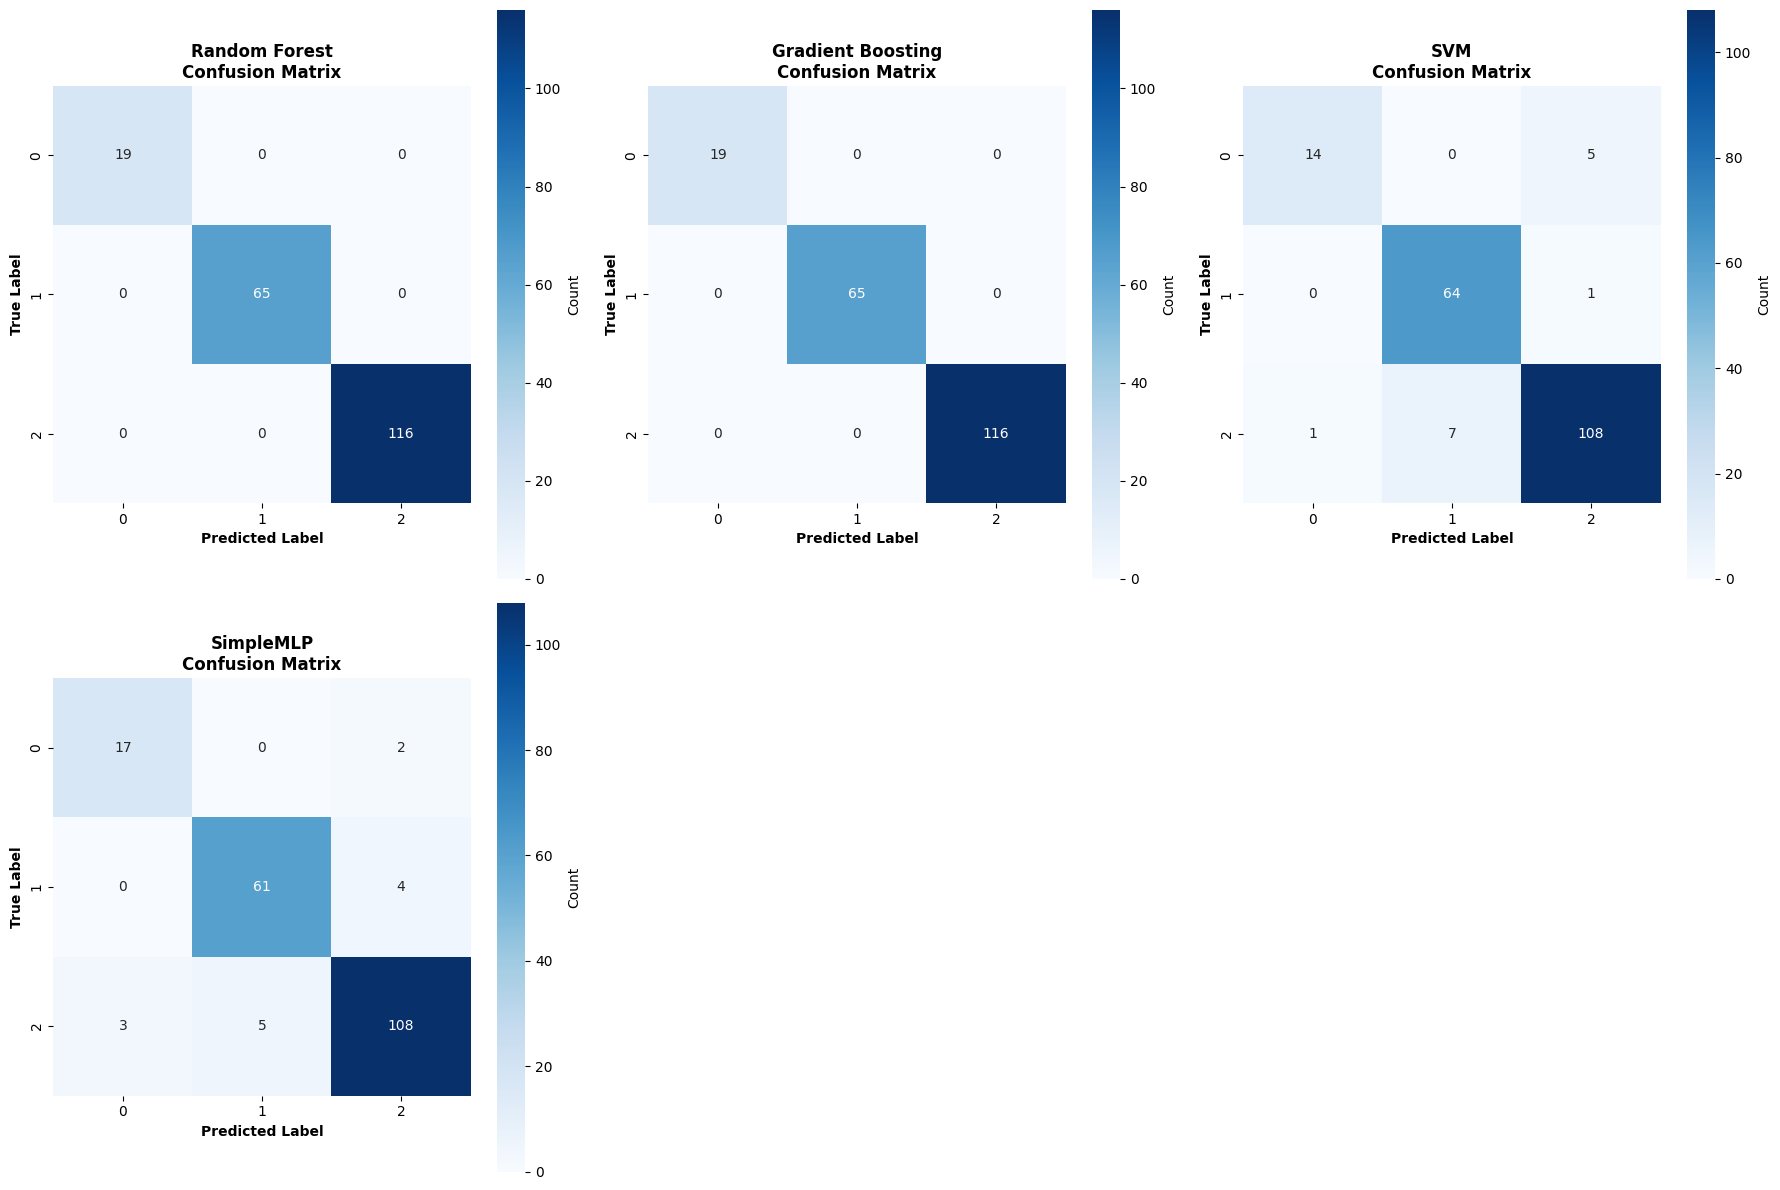

In [21]:
# 2. Confusion Matrix برای بهترین مدل‌ها
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

models_preds = [
    ('Random Forest', rf_pred),
    ('Gradient Boosting', gb_pred),
    ('SVM', svm_pred),
    ('SimpleMLP', preds),
    ('DeepMLP', None),  # باید از مدل ذخیره شده پیش‌بینی بگیریم
    ('ResidualMLP', None)
]

for idx, (name, pred) in enumerate(models_preds[:4]):
    ax = axes[idx // 3, idx % 3]
    cm = confusion_matrix(y_test, pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                cbar_kws={'label': 'Count'}, square=True)
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold', fontsize=12)
    ax.set_ylabel('True Label', fontweight='bold')
    ax.set_xlabel('Predicted Label', fontweight='bold')

# حذف محورهای اضافی
for idx in range(4, 6):
    fig.delaxes(axes[idx // 3, idx % 3])

plt.tight_layout()
plt.show()


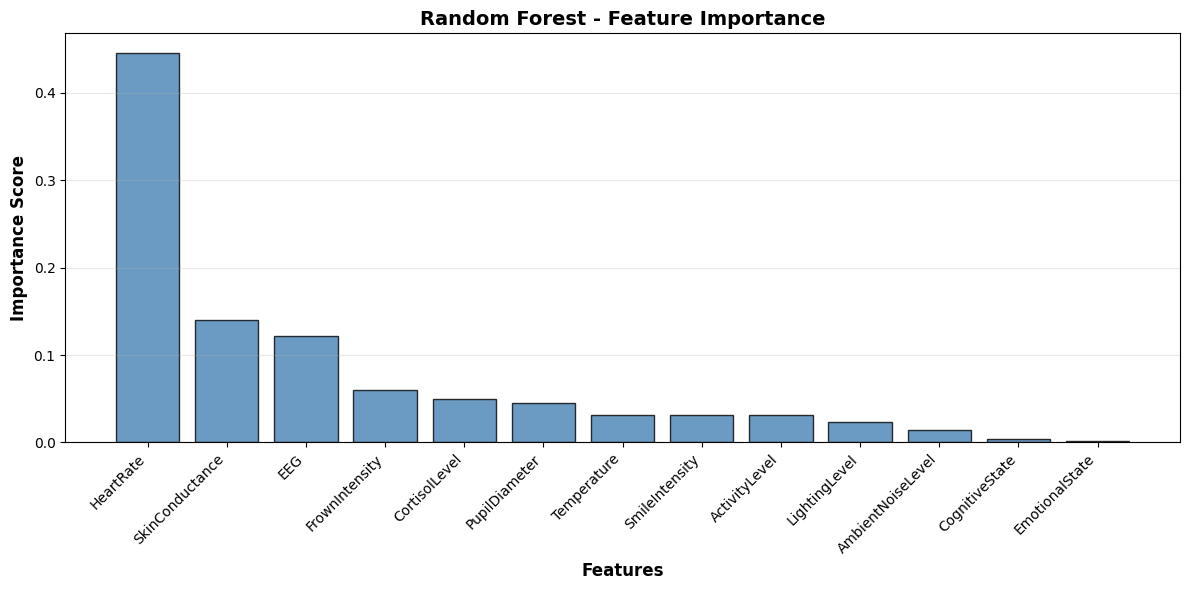


Feature Importance Ranking:
1. HeartRate: 0.4457
2. SkinConductance: 0.1403
3. EEG: 0.1215
4. FrownIntensity: 0.0604
5. CortisolLevel: 0.0500
6. PupilDiameter: 0.0447
7. Temperature: 0.0318
8. SmileIntensity: 0.0315
9. ActivityLevel: 0.0315
10. LightingLevel: 0.0238
11. AmbientNoiseLevel: 0.0139
12. CognitiveState: 0.0035
13. EmotionalState: 0.0014


In [22]:
# 3. Feature Importance برای Random Forest
feature_names = df.drop('EngagementLevel', axis=1).columns
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(len(importances)), importances[indices], color='steelblue', alpha=0.8, edgecolor='black')
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([feature_names[i] for i in indices], rotation=45, ha='right')
ax.set_ylabel('Importance Score', fontweight='bold', fontsize=12)
ax.set_xlabel('Features', fontweight='bold', fontsize=12)
ax.set_title('Random Forest - Feature Importance', fontweight='bold', fontsize=14)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# چاپ اهمیت ویژگی‌ها
print("\nFeature Importance Ranking:")
print("="*50)
for i in range(len(importances)):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")


In [23]:
# 4. منحنی یادگیری برای مدل‌های Deep Learning
# باید مدل‌ها را دوباره آموزش دهیم و تاریخچه را ذخیره کنیم

def train_with_history(model, train_loader, test_loader, epochs=150, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    test_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # محاسبه دقت تست
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                _, predicted = torch.max(outputs, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        
        test_acc = correct / total
        test_accuracies.append(test_acc)
    
    return train_losses, test_accuracies

# آموزش مجدد با ذخیره تاریخچه
print("Re-training models to capture learning curves...")

histories = {}
dl_models = {
    'SimpleMLP': SimpleMLP(input_dim, num_classes),
    'DeepMLP': DeepMLP(input_dim, num_classes),
    'ResidualMLP': ResidualMLP(input_dim, num_classes)
}

for name, model in dl_models.items():
    print(f"Training {name}...")
    train_loss, test_acc = train_with_history(model, train_loader, test_loader, epochs=150)
    histories[name] = {'train_loss': train_loss, 'test_acc': test_acc}


Re-training models to capture learning curves...
Training SimpleMLP...
Training DeepMLP...
Training ResidualMLP...


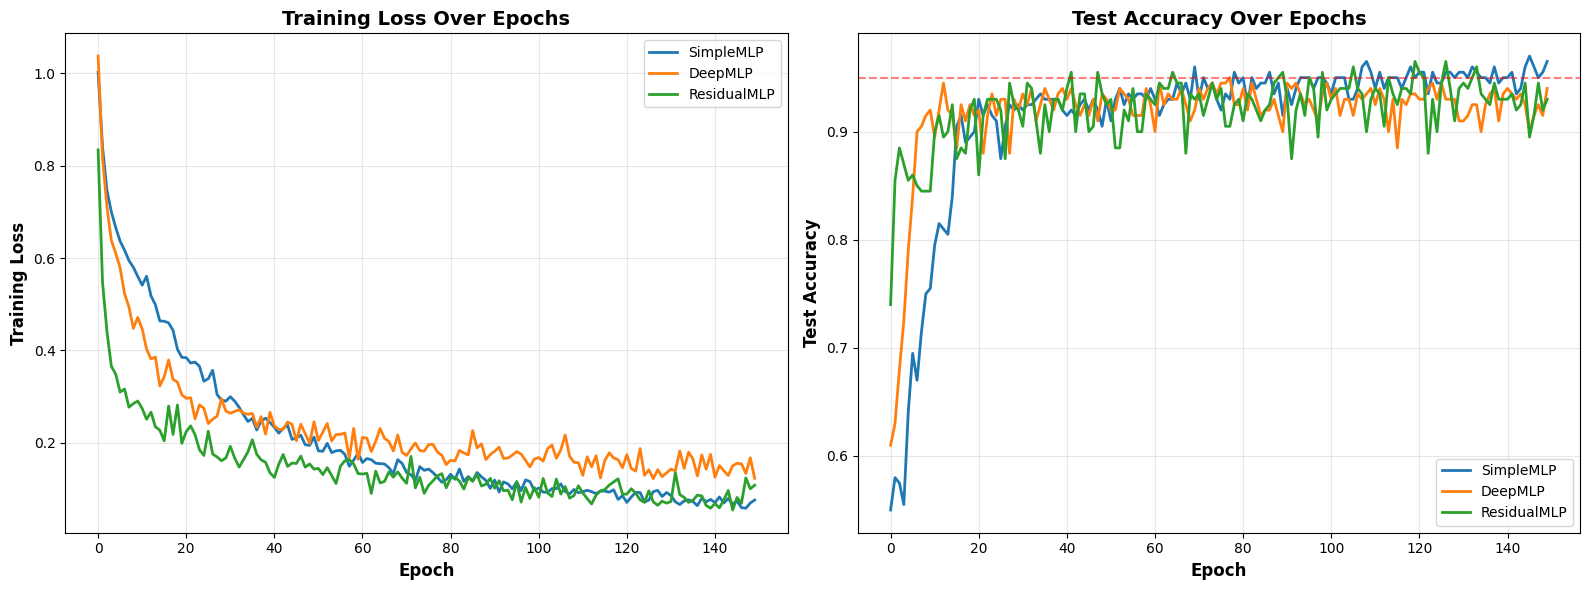

In [24]:
# 5. رسم منحنی‌های یادگیری
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training Loss
ax1 = axes[0]
for name, history in histories.items():
    ax1.plot(history['train_loss'], label=name, linewidth=2)

ax1.set_xlabel('Epoch', fontweight='bold', fontsize=12)
ax1.set_ylabel('Training Loss', fontweight='bold', fontsize=12)
ax1.set_title('Training Loss Over Epochs', fontweight='bold', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Test Accuracy
ax2 = axes[1]
for name, history in histories.items():
    ax2.plot(history['test_acc'], label=name, linewidth=2)

ax2.set_xlabel('Epoch', fontweight='bold', fontsize=12)
ax2.set_ylabel('Test Accuracy', fontweight='bold', fontsize=12)
ax2.set_title('Test Accuracy Over Epochs', fontweight='bold', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='95% threshold')

plt.tight_layout()
plt.show()


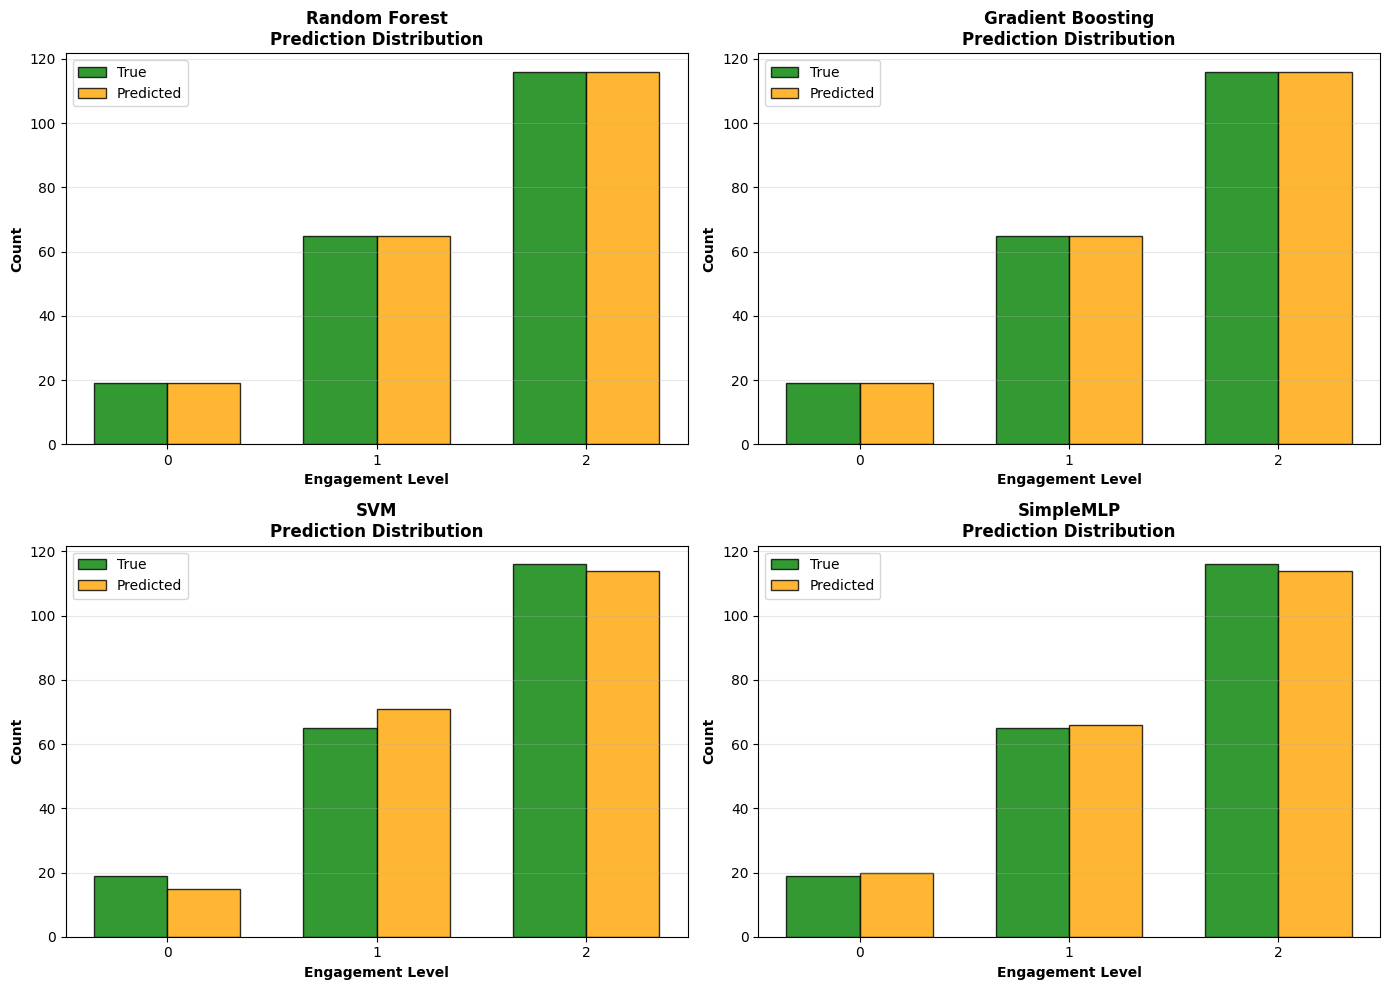

In [25]:
# 6. توزیع پیش‌بینی‌ها در مقابل واقعیت
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

predictions_dict = {
    'Random Forest': rf_pred,
    'Gradient Boosting': gb_pred,
    'SVM': svm_pred,
    'SimpleMLP': preds
}

for idx, (name, pred) in enumerate(predictions_dict.items()):
    ax = axes[idx // 2, idx % 2]
    
    # مقایسه توزیع
    x = np.arange(num_classes)
    width = 0.35
    
    true_counts = np.bincount(y_test, minlength=num_classes)
    pred_counts = np.bincount(pred, minlength=num_classes)
    
    ax.bar(x - width/2, true_counts, width, label='True', alpha=0.8, color='green', edgecolor='black')
    ax.bar(x + width/2, pred_counts, width, label='Predicted', alpha=0.8, color='orange', edgecolor='black')
    
    ax.set_xlabel('Engagement Level', fontweight='bold')
    ax.set_ylabel('Count', fontweight='bold')
    ax.set_title(f'{name}\nPrediction Distribution', fontweight='bold')
    ax.set_xticks(x)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


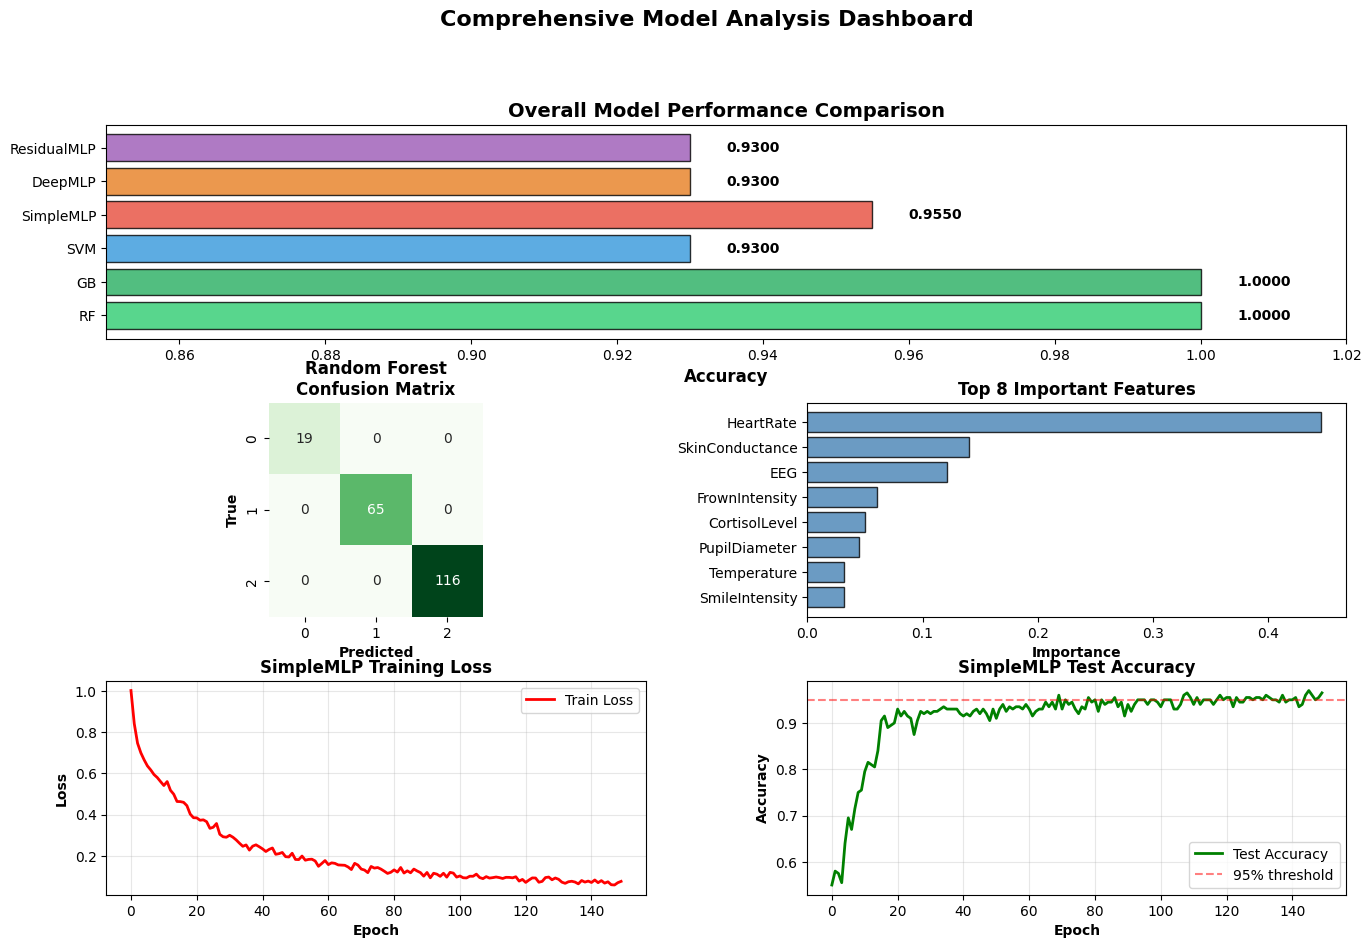

In [26]:
# 7. نمودار خلاصه نهایی - مقایسه جامع
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# دقت کلی
ax1 = fig.add_subplot(gs[0, :])
models_names = ['RF', 'GB', 'SVM', 'SimpleMLP', 'DeepMLP', 'ResidualMLP']
accuracies = [
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, gb_pred),
    accuracy_score(y_test, svm_pred),
    results['SimpleMLP'],
    results['DeepMLP'],
    results['ResidualMLP']
]
colors = ['#2ecc71', '#27ae60', '#3498db', '#e74c3c', '#e67e22', '#9b59b6']
bars = ax1.barh(models_names, accuracies, color=colors, alpha=0.8, edgecolor='black')
ax1.set_xlabel('Accuracy', fontweight='bold', fontsize=12)
ax1.set_title('Overall Model Performance Comparison', fontweight='bold', fontsize=14)
ax1.set_xlim([0.85, 1.02])
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    ax1.text(acc + 0.005, i, f'{acc:.4f}', va='center', fontweight='bold')

# Confusion Matrix بهترین مدل
ax2 = fig.add_subplot(gs[1, 0])
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax2, square=True, cbar=False)
ax2.set_title('Random Forest\nConfusion Matrix', fontweight='bold')
ax2.set_ylabel('True', fontweight='bold')
ax2.set_xlabel('Predicted', fontweight='bold')

# Feature Importance
ax3 = fig.add_subplot(gs[1, 1])
top_n = 8
top_indices = indices[:top_n]
ax3.barh(range(top_n), importances[top_indices][::-1], color='steelblue', alpha=0.8, edgecolor='black')
ax3.set_yticks(range(top_n))
ax3.set_yticklabels([feature_names[i] for i in top_indices][::-1])
ax3.set_xlabel('Importance', fontweight='bold')
ax3.set_title('Top 8 Important Features', fontweight='bold')

# منحنی یادگیری SimpleMLP
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(histories['SimpleMLP']['train_loss'], label='Train Loss', linewidth=2, color='red')
ax4.set_xlabel('Epoch', fontweight='bold')
ax4.set_ylabel('Loss', fontweight='bold')
ax4.set_title('SimpleMLP Training Loss', fontweight='bold')
ax4.grid(alpha=0.3)
ax4.legend()

# دقت تست SimpleMLP
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(histories['SimpleMLP']['test_acc'], label='Test Accuracy', linewidth=2, color='green')
ax5.axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='95% threshold')
ax5.set_xlabel('Epoch', fontweight='bold')
ax5.set_ylabel('Accuracy', fontweight='bold')
ax5.set_title('SimpleMLP Test Accuracy', fontweight='bold')
ax5.grid(alpha=0.3)
ax5.legend()

plt.suptitle('Comprehensive Model Analysis Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.show()
